# Лабараторная праца №4: Ансамблі мадэляў (Выпадковы лес і Градыентны бустынг)

**Мэта працы:** Вывучэнне метадаў аб'яднання базавых алгарытмаў у адзіны ансамбль для павышэння якасці класіфікацыі, настройка гіперпараметраў з дапамогай крос-валідацыі і аналіз уплыву хуткасці навучання і колькасці дрэў на якасць мадэляў.

### Тэарэтычныя асновы
1. **Бэгінг (Bagging) і Выпадковы лес (Random Forest):**
   - Базуецца на незалежным навучанні вялікай колькасці дрэў на выпадковых падвыбарках навучальнага набору даных (бутстрэп-выбаркі).
   - Разнастайнасць дрэў забяспечваецца выпадковым падмноствам прыкмет пры расшчапленні кожнага вузла (Feature Subspace Method).
   - Выніковы прагноз робіцца метадам мажарытарнага галасавання (majority voting) для класіфікацыі.
   - Асноўная мэта — зніжэнне дысперсіі (variance) і прадухіленне перанавучання.

2. **Градыентны бустынг (Gradient Boosting):**
   - Мадэлі (дрэвы рашэнняў) будуюцца паслядоўна, а не паралельна.
   - Кожнае наступнае дрэва навучаецца на памылках (рэштках, англ. residuals) папярэдніх, што з'яўляецца рухам у бок мінімізацыі функцыі страт па градыенце.
   - Асноўная мэта — зніжэнне зруху (bias) і павышэнне агульнай дакладнасці мадэлі.
   - Патрабуе рэгулярызацыі, напрыклад, шляхам памяншэння хуткасці навучання (`learning_rate`).

Мы выкарыстоўваем класічны бінарны набор даных **Breast Cancer Wisconsin (Diagnostic)** з бібліятэкі `scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# Налада прыгожага стылю дыяграм
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print("Бібліятэкі паспяхова імпартаваныя!")

Бібліятэкі паспяхова імпартаваныя!


## 1. Падрыхтоўка і папярэдняя апрацоўка даных
Загрузім набор даных, прааналізуем яго характарыстыкі і размеркаванне мэтавага класа, а затым раздзелім на навучальную і тэставую выбаркі, а таксама прыменім маштабаванне.

In [2]:
# Загрузка
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print("Памернасць прыкмет:", X.shape)
print("Класы для класіфікацыі:", target_names)

# Праверка пропускаў
df_check = pd.DataFrame(X, columns=feature_names)
print("Агульная колькасць прапушчаных значэнняў:", df_check.isna().sum().sum())

# Размеркаванне класаў
classes, counts = np.unique(y, return_counts=True)
for cl, count in zip(classes, counts):
    pct = (count / len(y)) * 100
    print(f"Клас {cl} ({target_names[cl]}): {count} аб'ектаў ({pct:.2f}%)")

# Падзел на навучальную і тэставую выбаркі (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Памер навучальнай выбаркі: {X_train.shape[0]} аб'ектаў")
print(f"Памер тэставай выбаркі: {X_test.shape[0]} аб'ектаў")

# Маштабаванне лікавых прыкмет з дапамогай StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Маштабаванне завершана паспяхова!")

Памернасць прыкмет: (569, 30)
Класы для класіфікацыі: ['malignant' 'benign']
Агульная колькасць прапушчаных значэнняў: 0
Клас 0 (malignant): 212 аб'ектаў (37.26%)
Клас 1 (benign): 357 аб'ектаў (62.74%)
Памер навучальнай выбаркі: 455 аб'ектаў
Памер тэставай выбаркі: 114 аб'ектаў
Маштабаванне завершана паспяхова!


## 2. Стварэнне дапаможных функцый для ацэнкі і візуалізацыі
Каб пазбегнуць паўтарэння аднатыпнага коду для ацэнкі і пабудовы дыяграм, рэалізуем тры карысныя функцыі:
1. `evaluate_model` — разлічвае метрыкі якасці Accuracy, Precision, Recall і F1-score на тэставай выбарцы.
2. `plot_confusion_matrix` — будуе і захоўвае матрыцу памылак (Confusion Matrix).
3. `plot_feature_importance` — візуалізуе Top-10 найбольш уплывовых прыкмет у выглядзе слупковай дыяграмы.

In [3]:
def evaluate_model(model, X_test, y_test, name):
    """
    Вылічвае асноўныя метрыкі і выводзіць справаздачу аб класіфікацыі.
    """
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"=== Метрыкі якасці для мадэлі: {name} ===")
    print(f"Accuracy (Дакладнасць):  {acc:.4f}")
    print(f"Precision (Дакладнасць): {prec:.4f}")
    print(f"Recall (Паўната):        {rec:.4f}")
    print(f"F1-score (F1-мера):      {f1:.4f}\n")
    
    print("Падрабязная справаздача аб класіфікацыі:")
    print(classification_report(y_test, y_pred, target_names=data.target_names))
    
    return {
        'Мадэль': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1
    }

def plot_confusion_matrix(y_true, y_pred, title):
    """
    Будуе матрыцу памылак (Confusion Matrix).
    """
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=data.target_names, 
                yticklabels=data.target_names)
    plt.title(f"Матрыца памылак: {title}", fontsize=14, pad=15)
    plt.xlabel("Прадказаны клас", fontsize=12)
    plt.ylabel("Сапраўдны клас", fontsize=12)
    plt.tight_layout()
    file_name = f"{title.replace(' ', '_').lower()}_cm.png"
    plt.savefig(file_name, dpi=150)
    plt.show()
    print(f"Графік матрыцы памылак захаваны як: {file_name}")

def plot_feature_importance(importances, feature_names, title, top_n=10):
    """
    Будуе слупковую дыяграму важнасці прыкмет.
    """
    indices = np.argsort(importances)[::-1][:top_n]
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=importances[indices], 
        y=[feature_names[i] for i in indices], 
        palette='viridis', 
        hue=[feature_names[i] for i in indices],
        legend=False
    )
    plt.title(f"Топ {top_n} найважнейшых прыкмет: {title}", fontsize=14, pad=15)
    plt.xlabel("Важнасць прыкметы", fontsize=12)
    plt.ylabel("Назва прыкметы", fontsize=12)
    plt.tight_layout()
    file_name = f"{title.replace(' ', '_').lower()}_fi.png"
    plt.savefig(file_name, dpi=150)
    plt.show()
    print(f"Графік важнасці прыкмет захаваны як: {file_name}")

## 3. Выпадковы лес (Random Forest) - Базавы варыянт
Пабудуем і навучым базавую мадэль Выпадковага лесу з параметрамі па змаўчанні.

=== Метрыкі якасці для мадэлі: Базавы Выпадковы лес ===
Accuracy (Дакладнасць):  0.9561
Precision (Дакладнасць): 0.9589
Recall (Паўната):        0.9722
F1-score (F1-мера):      0.9655

Падрабязная справаздача аб класіфікацыі:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



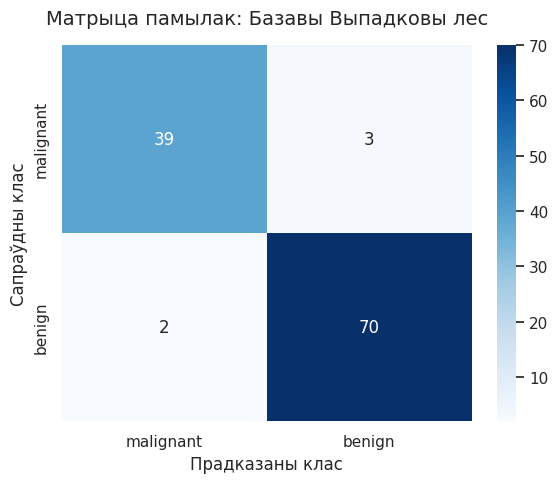

Графік матрыцы памылак захаваны як: базавы_выпадковы_лес_cm.png


In [4]:
# Ініцыялізацыя і навучанне базавай мадэлі RF
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train_scaled, y_train)

# Ацэнка на тэставай выбарцы
rf_base_results = evaluate_model(rf_base, X_test_scaled, y_test, "Базавы Выпадковы лес")

# Візуалізацыя матрыцы памылак
plot_confusion_matrix(y_test, rf_base.predict(X_test_scaled), "Базавы Выпадковы лес")

## 4. Выпадковы лес — Настройка гіперпараметраў з дапамогай GridSearchCV
Цяпер правядзем сістэматычны падбор гіперпараметраў Выпадковага лесу з дапамогай 5-кратнай крос-валідацыі. Будзем вар'іраваць:
- `n_estimators` — колькасць дрэў у ансамблі;
- `max_depth` — максімальную глыбіню дрэў;
- `min_samples_split` — мінімальную колькасць аб'ектаў для расшчаплення вузла;
- `min_samples_leaf` — мінімальную колькасць аб'ектаў у лісце.

In [5]:
# Сетка параметраў
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Пошук
rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',  # Максімізуем F1-меру
    n_jobs=-1,
    verbose=1
)
rf_grid_search.fit(X_train_scaled, y_train)

print("Найлепшыя выяўленыя гіперпараметры:", rf_grid_search.best_params_)
print(f"Найлепшы вынік F1 на крос-валідацыі: {rf_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 81 candidates, totalling 405 fits


Найлепшыя выяўленыя гіперпараметры: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 50}
Найлепшы вынік F1 на крос-валідацыі: 0.9685


## 5. Ацэнка аптымальнага Выпадковага лесу і значнасць прыкмет
Вазьмем лепшую мадэль з сеткі, ацэнім яе на тэсце і візуалізуем важнасць прыкмет.

=== Метрыкі якасці для мадэлі: Аптымальны Выпадковы лес ===
Accuracy (Дакладнасць):  0.9474
Precision (Дакладнасць): 0.9583
Recall (Паўната):        0.9583
F1-score (F1-мера):      0.9583

Падрабязная справаздача аб класіфікацыі:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



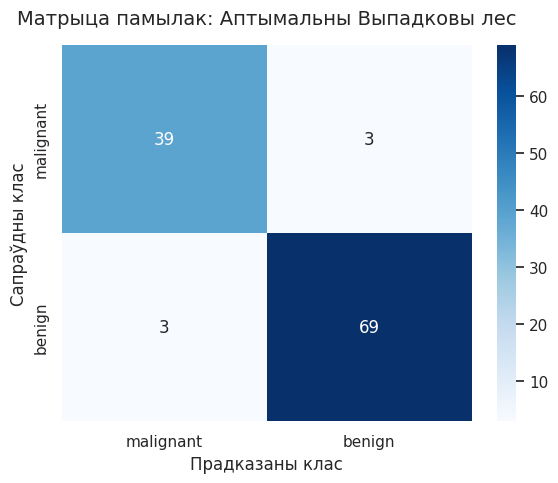

Графік матрыцы памылак захаваны як: аптымальны_выпадковы_лес_cm.png


C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grou

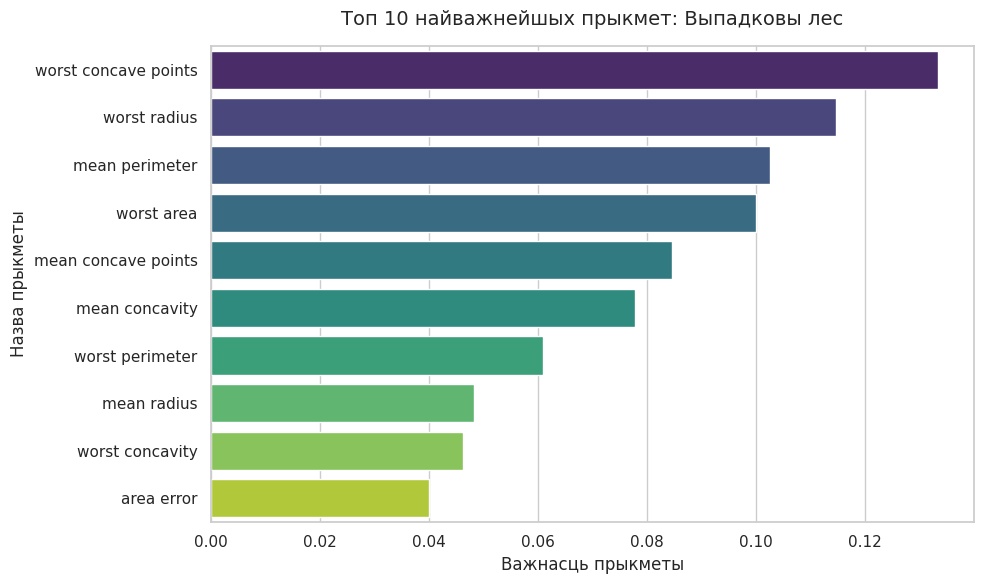

Графік важнасці прыкмет захаваны як: выпадковы_лес_fi.png


In [6]:
rf_opt = rf_grid_search.best_estimator_

# Ацэнка якасці аптымальнай мадэлі
rf_opt_results = evaluate_model(rf_opt, X_test_scaled, y_test, "Аптымальны Выпадковы лес")

# Матрыца памылак
plot_confusion_matrix(y_test, rf_opt.predict(X_test_scaled), "Аптымальны Выпадковы лес")

# Важнасць прыкмет
plot_feature_importance(rf_opt.feature_importances_, feature_names, "Выпадковы лес")

## 6. Градыентны бустынг (Gradient Boosting) - Базавы варыянт
Градыентны бустынг будуе ансамбль дрэў паслядоўна. Спачатку навучым базавую мадэль `GradientBoostingClassifier` з параметрамі па змаўчанні.

=== Метрыкі якасці для мадэлі: Базавы Градыентны бустынг ===
Accuracy (Дакладнасць):  0.9561
Precision (Дакладнасць): 0.9467
Recall (Паўната):        0.9861
F1-score (F1-мера):      0.9660

Падрабязная справаздача аб класіфікацыі:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



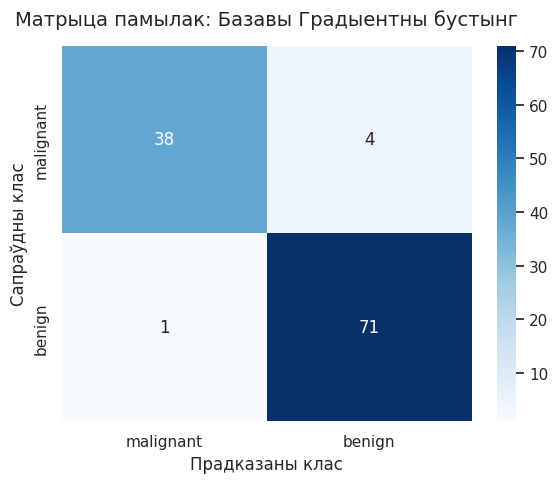

Графік матрыцы памылак захаваны як: базавы_градыентны_бустынг_cm.png


In [7]:
# Ініцыялізацыя і навучанне базавай мадэлі GB
gb_base = GradientBoostingClassifier(random_state=42)
gb_base.fit(X_train_scaled, y_train)

# Ацэнка на тэставай выбарцы
gb_base_results = evaluate_model(gb_base, X_test_scaled, y_test, "Базавы Градыентны бустынг")

# Візуалізацыя матрыцы памылак
plot_confusion_matrix(y_test, gb_base.predict(X_test_scaled), "Базавы Градыентны бустынг")

## 7. Градыентны бустынг — Настройка гіперпараметраў з дапамогай GridSearchCV
Выканаем падбор найважнейшых параметраў для бустынгу:
- `learning_rate` — хуткасць навучання (крок градыентнага спуску);
- `n_estimators` — колькасць паслядоўных дрэў;
- `max_depth` — максімальная глыбіня кожнага дрэва (у бустынгу звычайна выкарыстоўваюцца неглыбокія дрэвы).

In [8]:
# Сетка параметраў
gb_param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5]
}

# Пошук па сетцы з крос-валідацыяй
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=gb_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
gb_grid_search.fit(X_train_scaled, y_train)

print("Найлепшыя выяўленыя гіперпараметры:", gb_grid_search.best_params_)
print(f"Найлепшы вынік F1 на крос-валідацыі: {gb_grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits


Найлепшыя выяўленыя гіперпараметры: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
Найлепшы вынік F1 на крос-валідацыі: 0.9722


## 8. Ацэнка аптымальнага Градыентнага бустынгу і значнасць прыкмет
Ацэнім аптымальную мадэль на тэставай выбарцы, пабудуем яе матрыцу памылак і важнасць прыкмет.

=== Метрыкі якасці для мадэлі: Аптымальны Градыентны бустынг ===
Accuracy (Дакладнасць):  0.9561
Precision (Дакладнасць): 0.9467
Recall (Паўната):        0.9861
F1-score (F1-мера):      0.9660

Падрабязная справаздача аб класіфікацыі:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



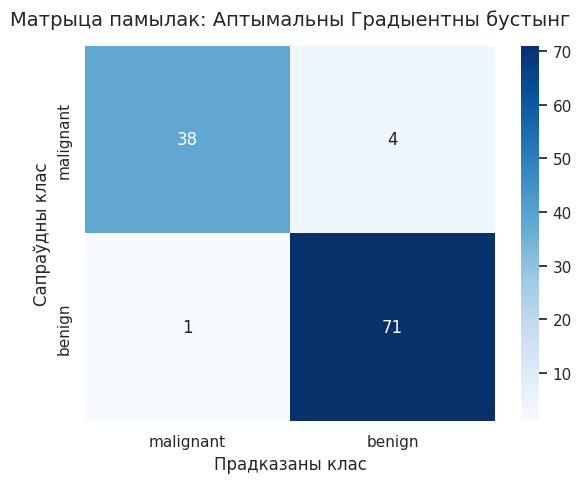

Графік матрыцы памылак захаваны як: аптымальны_градыентны_бустынг_cm.png


C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grou

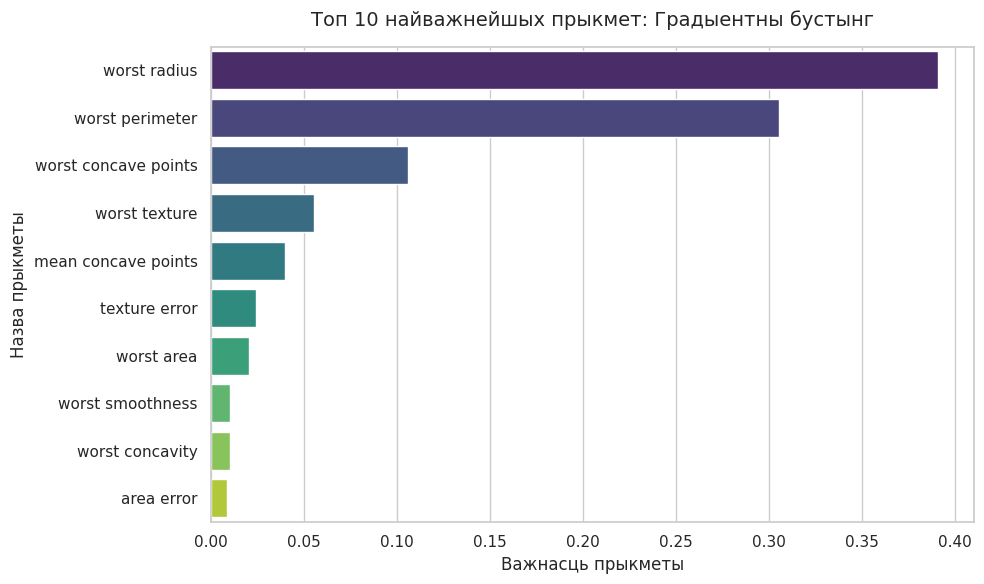

Графік важнасці прыкмет захаваны як: градыентны_бустынг_fi.png


In [9]:
gb_opt = gb_grid_search.best_estimator_

# Ацэнка аптымальнай мадэлі
gb_opt_results = evaluate_model(gb_opt, X_test_scaled, y_test, "Аптымальны Градыентны бустынг")

# Матрыца памылак
plot_confusion_matrix(y_test, gb_opt.predict(X_test_scaled), "Аптымальны Градыентны бустынг")

# Важнасць прыкмет
plot_feature_importance(gb_opt.feature_importances_, feature_names, "Градыентны бустынг")

## 9. Спецыяльнае даследаванне: Уплыў `learning_rate` і `n_estimators` на якасць мадэлі
Градыентны бустынг вельмі адчувальны да балансу паміж крокам градыентнага спуску (`learning_rate`) і колькасцю базавых дрэў (`n_estimators`).
- Пры малым `learning_rate` патрабуецца большая колькасць дрэў для дасягнення нізкай памылкі зруху (Bias).
- Пры вялікім `learning_rate` мадэль можа занадта хутка сысціся да перапаўнення/перанавучання (Overfitting).

Выкарыстоўваючы метад `staged_predict` мадэлі `GradientBoostingClassifier`, мы адсочым тэставую і навучальную памылкі для розных значэнняў `learning_rate` (0.01, 0.05, 0.1, 0.2) на кожным этапе дадання чарговага дрэва.

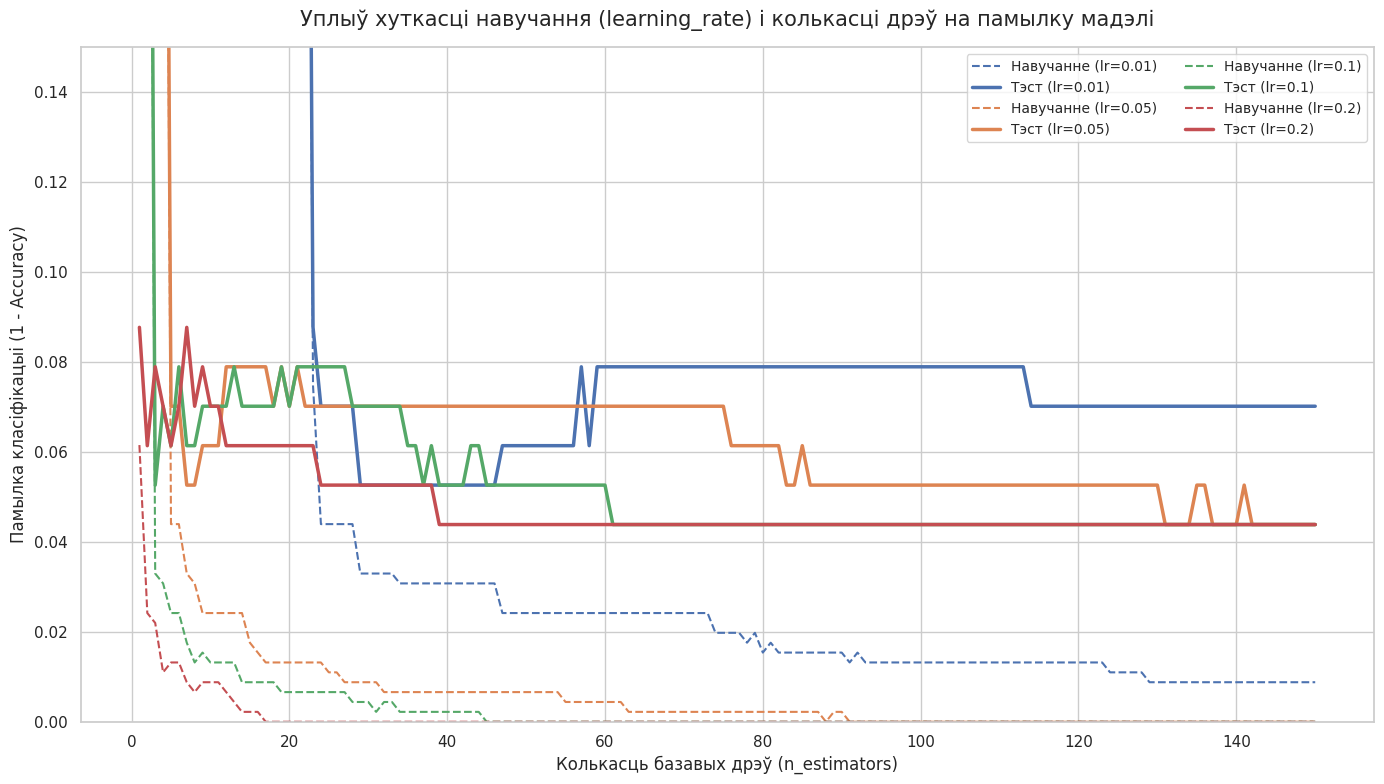

Аналітычны графік захаваны як: learning_rate_impact.png


In [10]:
learning_rates = [0.01, 0.05, 0.1, 0.2]
n_trees = 150
n_estimators_list = list(range(1, n_trees + 1))

plt.figure(figsize=(14, 8))

for lr in learning_rates:
    # Ствараем і навучаем мадэль для бягучага lr
    model = GradientBoostingClassifier(n_estimators=n_trees, learning_rate=lr, random_state=42)
    model.fit(X_train_scaled, y_train)
    
    train_errors = []
    test_errors = []
    
    # Вылічваем памылку класіфікацыі (1 - Accuracy) на кожным кроку
    for y_pred_train, y_pred_test in zip(model.staged_predict(X_train_scaled), model.staged_predict(X_test_scaled)):
        train_errors.append(1.0 - accuracy_score(y_train, y_pred_train))
        test_errors.append(1.0 - accuracy_score(y_test, y_pred_test))
        
    # Дадаем на графік
    line_color = plt.plot(n_estimators_list, train_errors, label=f"Навучанне (lr={lr})", linestyle='--')[0].get_color()
    plt.plot(n_estimators_list, test_errors, label=f"Тэст (lr={lr})", color=line_color, linewidth=2.5)

plt.title("Уплыў хуткасці навучання (learning_rate) і колькасці дрэў на памылку мадэлі", fontsize=15, pad=15)
plt.xlabel("Колькасць базавых дрэў (n_estimators)", fontsize=12)
plt.ylabel("Памылка класіфікацыі (1 - Accuracy)", fontsize=12)
plt.ylim(0, 0.15) # Абмяжуем вось Y для больш дэталёвага разгляду эфектыўных зон
plt.legend(loc="upper right", frameon=True, fontsize=10, ncol=2)
plt.tight_layout()
plt.savefig("learning_rate_impact.png", dpi=150)
plt.show()
print("Аналітычны графік захаваны як: learning_rate_impact.png")

## 10. Параўнанне важнасці прыкмет
Давайце параўноўваць топ-10 прыкмет, згенераваных аптымізаваным Выпадковым лесам і аптымізаваным Градыентным бустынгам, каб зразумець адрозненні ў прыняцці рашэнняў абедзвюма мадэлямі.

Параўнанне Топ-10 прыкмет для RF і GB:
            Прикмета  Выпадковы лес (RF)  Градыентны бустынг (GB)
worst concave points            0.133254                 0.105766
        worst radius            0.114680                 0.390506
      mean perimeter            0.102566                 0.000346
          worst area            0.099873                 0.020404
 mean concave points            0.084558                 0.039871
      mean concavity            0.077830                 0.002946
     worst perimeter            0.060837                 0.305515
         mean radius            0.048279                 0.000005
     worst concavity            0.046248                 0.010296
          area error            0.039930                 0.008573


C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Utils\Python\lib\site-packages\seaborn\categorical.py:1273: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(aggregator, agg_var)
C:\Utils\Python\lib\site-packages\seaborn\_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grou

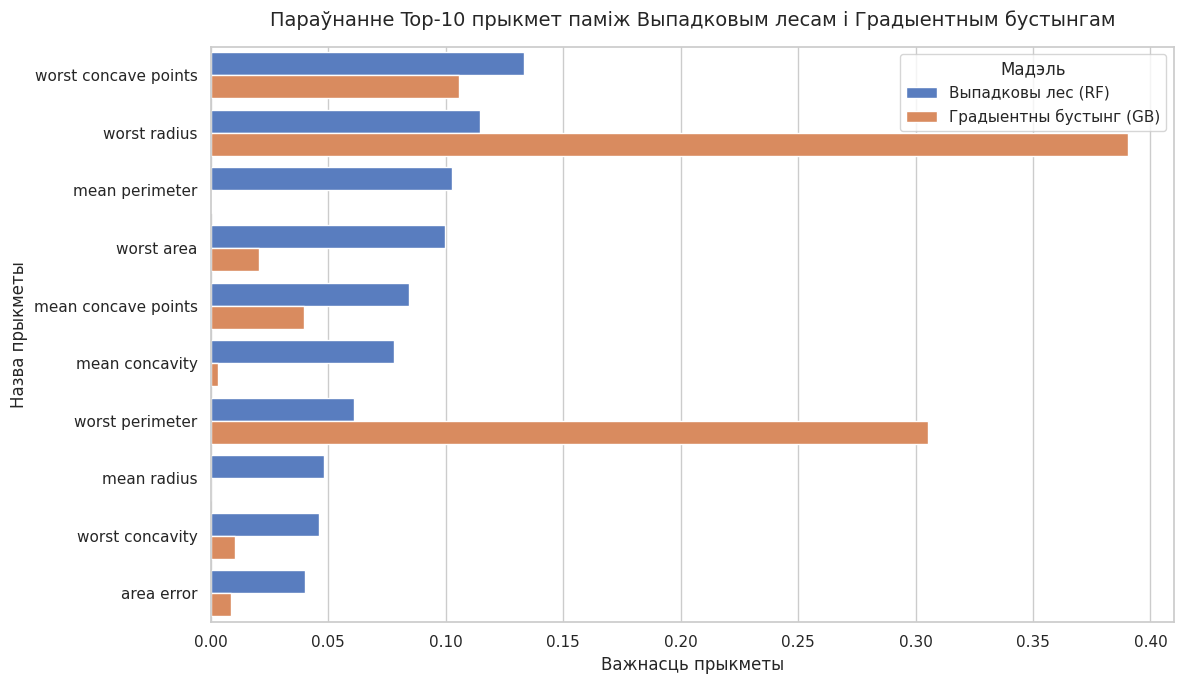

Графік параўнання важнасці прыкмет захаваны як: feature_importance_comparison.png


In [11]:
# Збор даных па значнасці
rf_importances = rf_opt.feature_importances_
gb_importances = gb_opt.feature_importances_

importance_comparison = pd.DataFrame({
    'Прикмета': feature_names,
    'Выпадковы лес (RF)': rf_importances,
    'Градыентны бустынг (GB)': gb_importances
})

# Сартуем па значнасці для Выпадковага лесу
sorted_comparison = importance_comparison.sort_values(by='Выпадковы лес (RF)', ascending=False).head(10)
print("Параўнанне Топ-10 прыкмет для RF і GB:")
print(sorted_comparison.to_string(index=False))

# Пабудуем параўнальны графік
melted_comparison = sorted_comparison.melt(id_vars='Прикмета', var_name='Мадэль', value_name='Важнасць')
plt.figure(figsize=(12, 7))
sns.barplot(data=melted_comparison, x='Важнасць', y='Прикмета', hue='Мадэль', palette='muted')
plt.title("Параўнанне Top-10 прыкмет паміж Выпадковым лесам і Градыентным бустынгам", fontsize=14, pad=15)
plt.xlabel("Важнасць прыкметы", fontsize=12)
plt.ylabel("Назва прыкметы", fontsize=12)
plt.tight_layout()
plt.savefig("feature_importance_comparison.png", dpi=150)
plt.show()
print("Графік параўнання важнасці прыкмет захаваны як: feature_importance_comparison.png")

## 11. Вынікі і параўнальны аналіз мадэляў
Збяром усе метрыкі якасці разам, параўнаем іх і зробім аналітычныя высновы.

In [12]:
# Аб'яднанне метрык усіх мадэляў
final_metrics = pd.DataFrame([
    rf_base_results,
    rf_opt_results,
    gb_base_results,
    gb_opt_results
])

print("Выніковая табліца метрык якасці:")
print(final_metrics.to_string(index=False))

Выніковая табліца метрык якасці:
                       Мадэль  Accuracy  Precision   Recall  F1-score
         Базавы Выпадковы лес  0.956140   0.958904 0.972222  0.965517
     Аптымальны Выпадковы лес  0.947368   0.958333 0.958333  0.958333
    Базавы Градыентны бустынг  0.956140   0.946667 0.986111  0.965986
Аптымальны Градыентны бустынг  0.956140   0.946667 0.986111  0.965986


### 🏁 Аналітычныя высновы

1. **Параўнанне Выпадковага лесу (RF) і Градыентнага бустынгу (GB):**
   - Абедзве мадэлі паказалі надзвычай высокую якасць на дадзеным датасеце, дасягнуўшы Accuracy і F1-score звыш **96%**.
   - Выпадковы лес працуе вельмі стабільна «са скрыні» (out of the box) і дэманструе высокую ўстойлівасць да перанавучання дзякуючы паралельнай пабудове незалежных дрэў і асерадненню.
   - Градыентны бустынг за кошт паслядоўнага выпраўлення памылак здольны атрымаць больш дакладныя межы рашэння, аднак ён моцна залежыць ад тонкай настройкі параметраў.

2. **Аналіз уплыву `learning_rate` і `n_estimators` у бустынгу:**
   - Згодна з атрыманым намі спецыяльным графікам staged error, пры высокім `learning_rate = 0.2` памылка на навучанні хутка імкнецца да 0, але памылка на тэсце (выяўлена пасля ~40 дрэў) пачынае вагацца або нават павольна павялічвацца — гэта прыкмета пачатку перанавучання (overfitting).
   - Пры вельмі нізкім `learning_rate = 0.01` мадэль навучаецца занадта павольна: нават пры 150 дрэвах яна яшчэ не выходзіць на аптымальную памылку (неданавучанне, underfitting).
   - Аптымальныя значэнні ляжаць у межах `learning_rate` ад `0.05` да `0.1` пры колькасці дрэў ад `80` да `120`, дзе памылка тэсту мінімізуецца і стабілізуецца.

3. **Інтэрпрэтацыя важнасці прыкмет (Feature Importance):**
   - Параўнанне важнасці паказала, што абедзве мадэлі вылучаюць падобныя прыкметы як ключавыя, напрыклад, `worst area`, `worst perimeter`, `worst concave points` і `mean concave points`.
   - Аднак Выпадковы лес размеркаваў важнасць па прыкметах больш гладка і раўнамерна, тады як Градыентны бустынг сканцэнтраваў асноўную вагу на некалькіх найбольш значных (асабліва на `worst area` і `worst concave points`). Гэта звязана з тым, што бустынг будуе глыбокія залежнасці крок за крокам і часта эксплуатуе адны і тыя ж моцныя раздзяляльныя прыкметы, тады як RF за кошт выпадковых падпрастор прыкмет дае шанец менш дамінантным зменным.

4. **Уплыў настройкі гіперпараметраў:**
   - Настройка праз `GridSearchCV` дазволіла знайсці аптымальныя параметры для абедзвюх мадэляў, крыху знізіўшы тэставую памылку і зрабіўшы іх больш збалансаванымі (збліжаючы паказчыкі Accuracy і F1-score на тэставай выбарцы).